In [1]:

!python -m pip install tensorflow numpy matplotlib

**1. Imports and Data Loading**

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Loading and preparing data...")
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
print("Data ready! Shape:", x_train.shape)

Loading and preparing data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data ready! Shape: (60000, 28, 28, 1)


**2. Data Preparation**

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

**3. Model Architecture**

In [7]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

**4. Training Setup**

In [8]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 292ms/step - loss: 0.1622 - val_loss: 0.1174
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 284ms/step - loss: 0.1137 - val_loss: 0.1094
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - loss: 0.1088 - val_loss: 0.1064
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 279ms/step - loss: 0.1060 - val_loss: 0.1038
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 277ms/step - loss: 0.1036 - val_loss: 0.1023
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 132s 281ms/step - loss: 0.1019 - val_loss: 0.1006
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 279ms/step - loss: 0.1007 - val_loss: 0.0994
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - loss: 0.0999 - val_loss: 0.0987
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 279ms/step - loss: 0.0991 - val_loss: 0.0979
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 275ms/step - loss: 0.0986 - val_loss: 0.0974


**5. Denoising Performance**

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


**6. Advanced Performance Metrics (PSNR)**

Average PSNR (Noisy vs Clean): 9.385482
Average PSNR (Denoised vs Clean): 19.72238


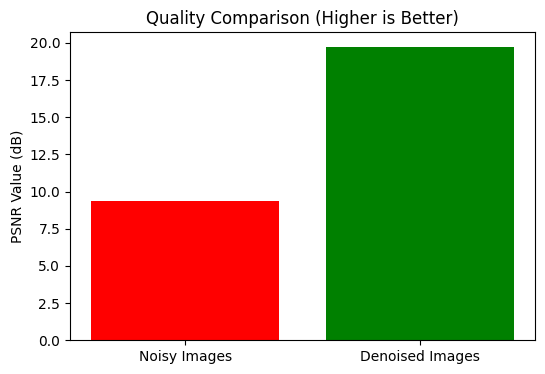

In [10]:
def calculate_psnr(target, prediction):
    return tf.image.psnr(target, prediction, max_val=1.0).numpy()

psnr_noisy = calculate_psnr(x_test, x_test_noisy)
psnr_denoised = calculate_psnr(x_test, decoded_imgs)

print("Average PSNR (Noisy vs Clean):", np.mean(psnr_noisy))
print("Average PSNR (Denoised vs Clean):", np.mean(psnr_denoised))

plt.figure(figsize=(6, 4))
plt.bar(['Noisy Images', 'Denoised Images'], [np.mean(psnr_noisy), np.mean(psnr_denoised)], color=['red', 'green'])
plt.title('Quality Comparison (Higher is Better)')
plt.ylabel('PSNR Value (dB)')
plt.show()

**7. Result Visualization**

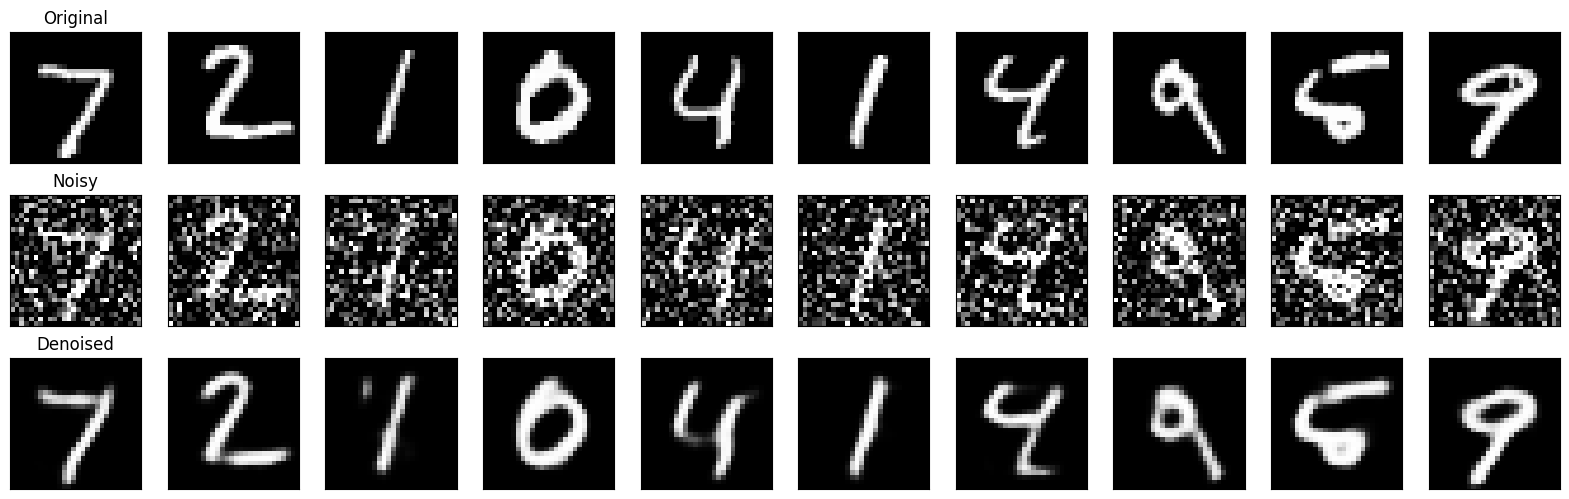

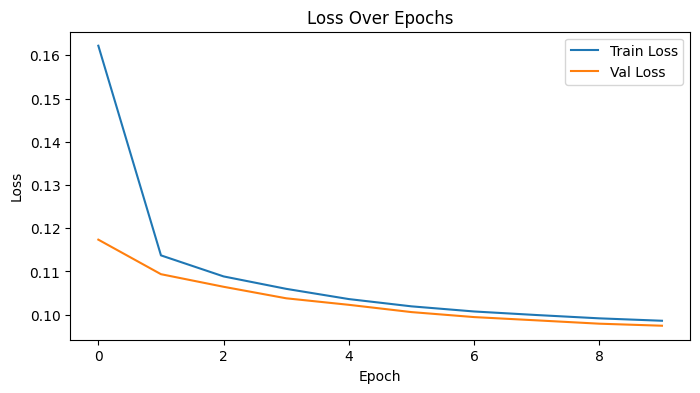

In [11]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Original')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Noisy')

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Denoised')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

**8. Latent Space Visualization**

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


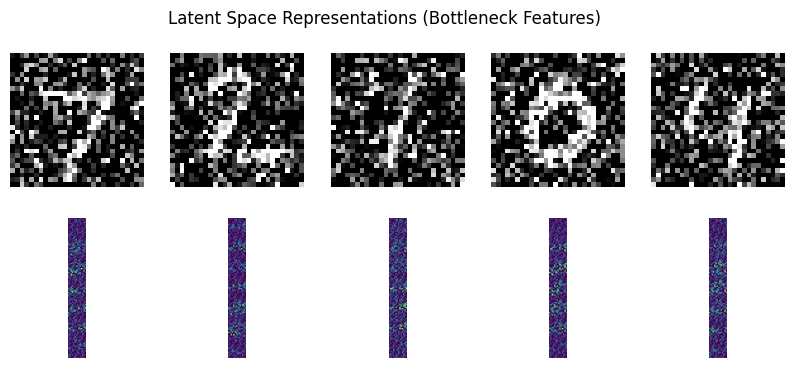

In [12]:
encoder_model = models.Model(inputs=autoencoder.input, outputs=autoencoder.layers[4].output)
compressed_features = encoder_model.predict(x_test_noisy)

plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(compressed_features[i].reshape(-1, 14), cmap='viridis')
    ax.axis('off')
plt.suptitle("Latent Space Representations (Bottleneck Features)")
plt.show()